In [1]:
# Importação de bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

In [3]:
# Leitura dos dataframes
dados = pd.read_pickle('../dados/dados_tratados.pkl')
dados_com_artist = pd.read_csv('../dados/dados_pos_an_exp.csv')

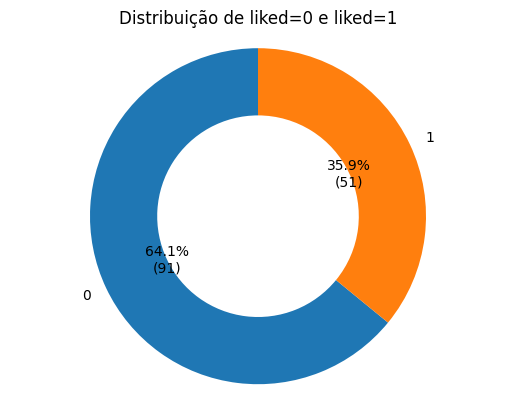

In [4]:
# Gráfico distribuição de liked=0 e liked=1
contagem = dados['liked'].value_counts()
plt.pie(contagem, labels=contagem.index.astype(str), autopct=lambda p: '{:.1f}%\n({:.0f})'.format(p, p * sum(contagem) / 100), startangle=90, wedgeprops=dict(width=0.4))
plt.title('Distribuição de liked=0 e liked=1')
plt.axis('equal')  # para ficar um círculo perfeito
plt.savefig('../graficos/Gráfico distribuição de liked=0 e liked=1.png', dpi=300)
plt.show()

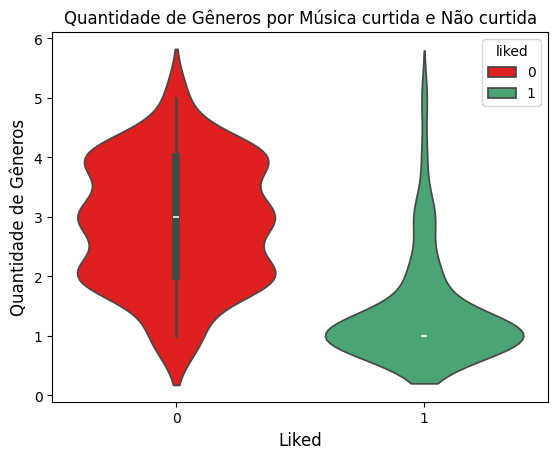

In [5]:
# Gráfico qt de gênero por música curtida e não curtida
sns.violinplot(data=dados, x='liked', y='qt_genres', hue='liked', palette=['red', 'mediumseagreen'])
plt.title('Quantidade de Gêneros por Música curtida e Não curtida')
plt.xlabel('Liked', fontsize=12)
plt.ylabel('Quantidade de Gêneros', fontsize=12)
plt.savefig('../graficos/Gráfico qt de gênero por música curtida e não curtida.png', dpi=300)

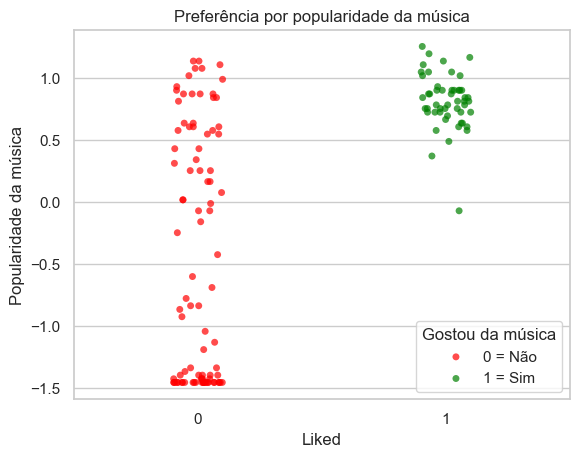

In [6]:
# Gráfico preferência por popularidade da música
sns.set(style='whitegrid')
sns.stripplot(x='liked', y='music_popularity', data=dados, jitter=True, hue='liked', palette={0: 'red', 1: 'green'}, alpha=0.7, dodge=False)
plt.legend(title='Gostou da música', labels=['0 = Não', '1 = Sim'])
plt.title('Preferência por popularidade da música')
plt.xlabel('Liked', fontsize=12)
plt.ylabel('Popularidade da música', fontsize=12)
plt.savefig('../graficos/Gráfico preferência por popularidade da música.png', dpi=300)
plt.show()

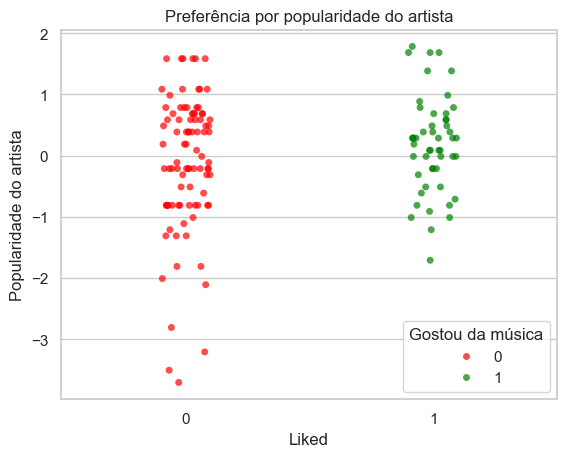

In [7]:
# Gráfico preferência por popularidade do artista
sns.set(style='whitegrid')
sns.stripplot(x='liked', y='artist_popularity', data=dados, jitter=True, hue='liked', palette={0: 'red', 1: 'green'}, alpha=0.7, dodge=False)
plt.legend(title='Gostou da música')
plt.title('Preferência por popularidade do artista')
plt.xlabel('Liked', fontsize=12)
plt.ylabel('Popularidade do artista', fontsize=12)
plt.savefig('../graficos/Gráfico preferência por popularidade do artista.png', dpi=300)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

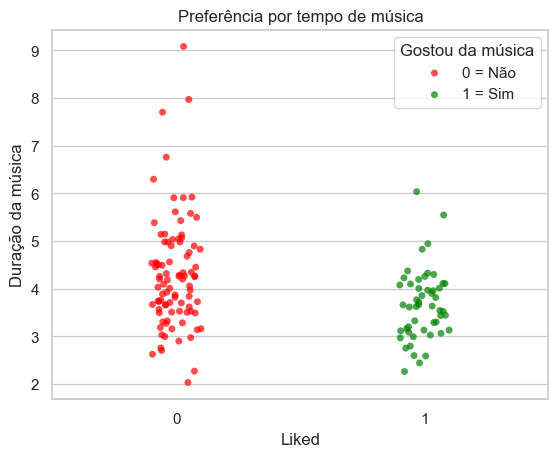

In [8]:
# Gráfico preferência por tempo de música
sns.set(style='whitegrid')
sns.stripplot(x='liked', y='duration_min', data=dados, jitter=True, hue='liked', palette={0: 'red', 1: 'green'}, alpha=0.7, dodge=False)
plt.legend(title='Gostou da música', labels=['0 = Não', '1 = Sim'])
plt.title('Preferência por tempo de música')
plt.xlabel('Liked', fontsize=12)
plt.ylabel('Duração da música', fontsize=12)
plt.savefig('../graficos/Gráfico preferência por tempo de música.png', dpi=300)
plt.show

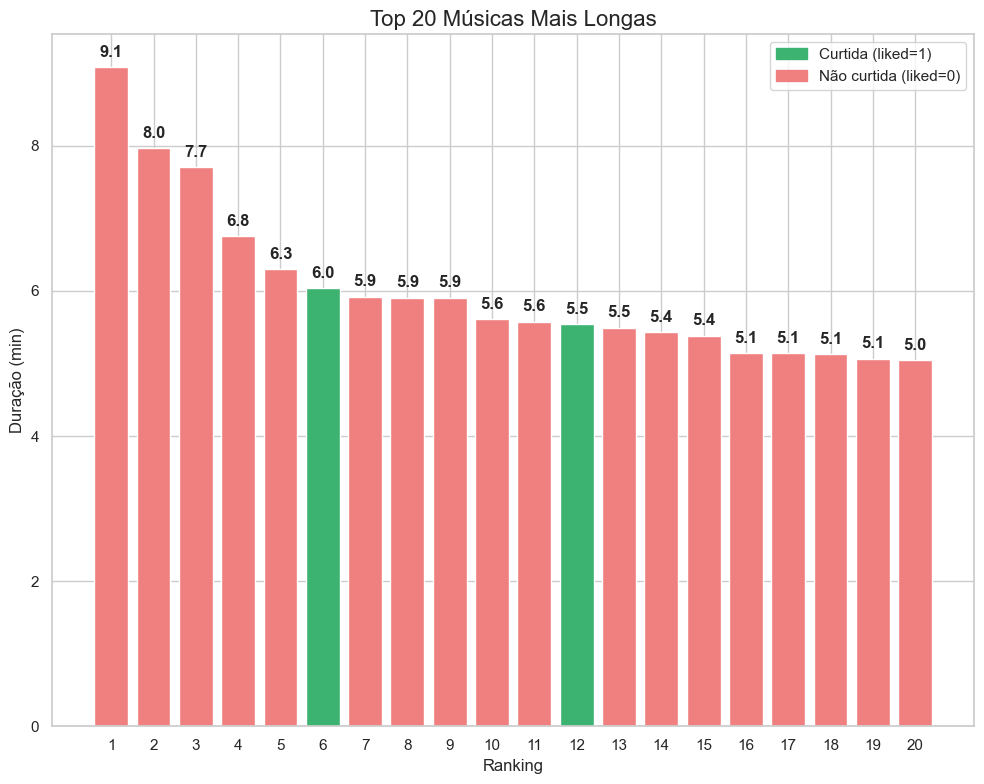

In [9]:
# Gráfico top 20 músicas mais longas
top_20_longas = dados.sort_values(by='duration_min', ascending=False).head(20)
top_20_longas['rank'] = range(1, 21)
cores = ['mediumseagreen' if liked == 1 else 'lightcoral' for liked in top_20_longas['liked']]
plt.figure(figsize=(10,8))
bars = plt.bar(top_20_longas['rank'], top_20_longas['duration_min'], color=cores)
for bar, duracao in zip(bars, top_20_longas['duration_min']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{duracao:.1f}', ha='center', va='bottom', fontweight='bold')
plt.title('Top 20 Músicas Mais Longas', fontsize=16)
plt.xlabel('Ranking', fontsize=12)
plt.ylabel('Duração (min)', fontsize=12)
plt.xticks(top_20_longas['rank'])
import matplotlib.patches as mpatches
plt.legend(handles=[
    mpatches.Patch(color='mediumseagreen', label='Curtida (liked=1)'),
    mpatches.Patch(color='lightcoral', label='Não curtida (liked=0)')])
plt.tight_layout()
plt.savefig('../graficos/Gráfico top 20 músicas mais longas.png', dpi=400)
plt.show()

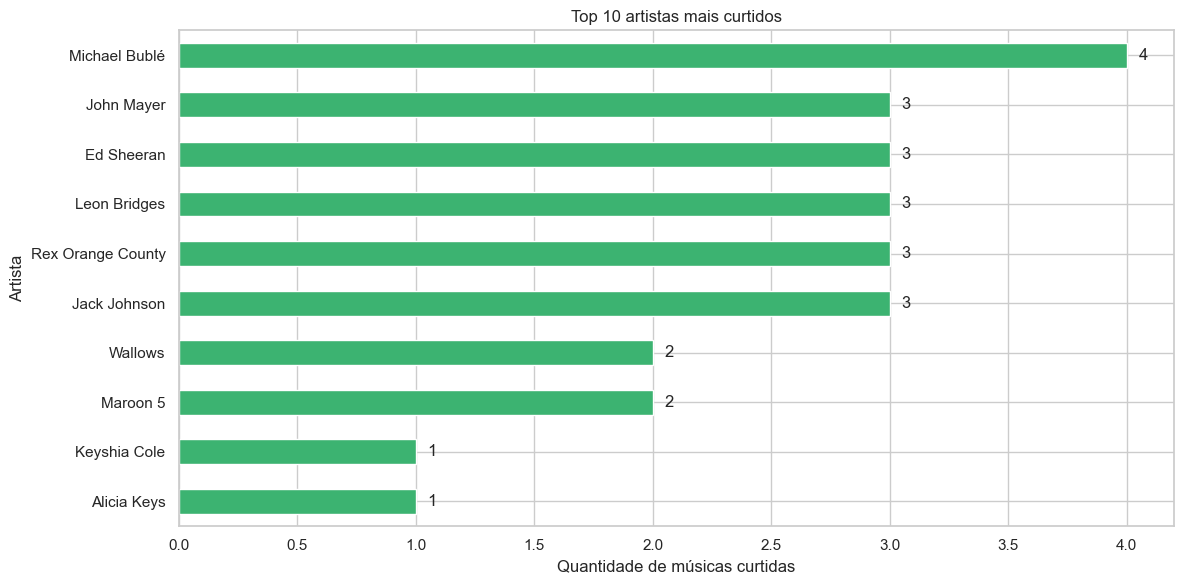

In [10]:
# Gráfico top 10 artistas mais curtidos
liked_by_artist = dados_com_artist[dados_com_artist['liked'] == 1]['artist'].value_counts().head(10)
plt.figure(figsize=(12, 6))
ax = liked_by_artist.plot(kind='barh', color='mediumseagreen')
for bar in ax.patches:
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, str(int(bar.get_width())), va='center')
plt.title('Top 10 artistas mais curtidos')
plt.xlabel('Quantidade de músicas curtidas')
plt.ylabel('Artista')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig('../graficos/Gráfico top 10 artistas mais curtidos.png', dpi=400)
plt.show()

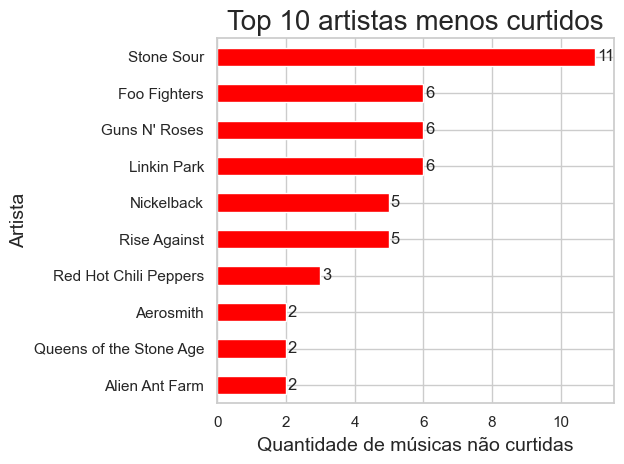

In [11]:
# Gráfico top 10 artistas menos curtidos
liked_by_artist = dados_com_artist[dados_com_artist['liked'] == 0]['artist'].value_counts().head(10)
ax = liked_by_artist.plot(kind='barh', color='red')
plt.title('Top 10 artistas menos curtidos', fontsize=20)
plt.xlabel('Quantidade de músicas não curtidas', fontsize=14)
plt.ylabel('Artista', fontsize=14)
for bar in ax.patches:
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, str(int(bar.get_width())), va='center')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig('../graficos/Gráfico top 10 artistas menos curtidos.png', dpi=400)
plt.show()

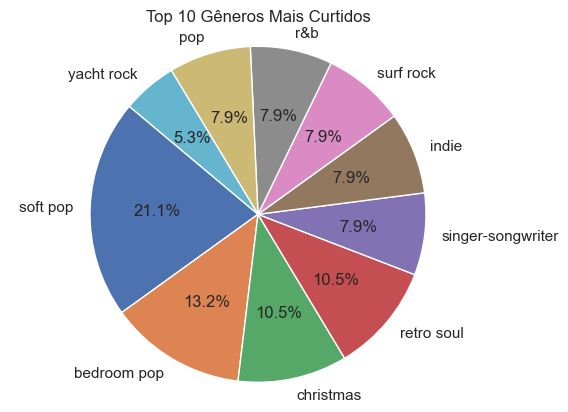

In [12]:
# Gráfico top 10 gêneros mais curtidos
colunas_genero = dados.columns[5:78]
generos_curtidos = dados[dados['liked'] == 1][colunas_genero].sum()
top_generos_curtidos = generos_curtidos.sort_values(ascending=False).head(10)
plt.pie(top_generos_curtidos, labels=top_generos_curtidos.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Gêneros Mais Curtidos')
plt.axis('equal')
plt.savefig('../graficos/Gráfico top 10 gêneros mais curtidos.png', dpi=300)
plt.show()

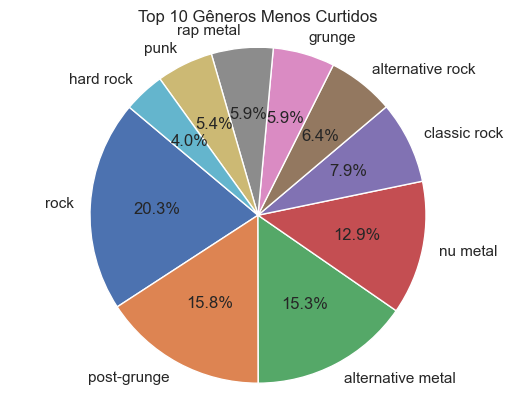

In [13]:
# Gráfico top 10 gêneros menos curtidos
colunas_genero = dados.columns[5:78]
generos_nao_curtidos = dados[dados['liked'] == 0][colunas_genero].sum()
top_generos_nao_curtidos = generos_nao_curtidos.sort_values(ascending=False).head(10)
plt.pie(top_generos_nao_curtidos, labels=top_generos_nao_curtidos.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Gêneros Menos Curtidos')
plt.axis('equal')
plt.savefig('../graficos/Gráfico top 10 gêneros menos curtidos.png', dpi=300)
plt.show()